# 02 - ML Pipeline Multiclass

Full model selection and fine-tuning, OOD evaluation, and interpretability
for WoT and Dota at 3-class granularity — chosen in 01_granularity_experiment.ipynb.

In [4]:
# imports
import warnings, json
from pathlib import Path
warnings.filterwarnings('ignore')
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report
from sklearn.calibration import CalibratedClassifierCV

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from optuna.samplers import TPESampler
import joblib

import sys
sys.path.insert(0, str(Path('../..')))
from src.tokenizer import tokenize
from src.scoring import cv_score, holdout_score, ood_score, make_f1_scorer

# project root and data paths
PROJECT_ROOT = Path().resolve().parents[1]
DATA_WOT     = PROJECT_ROOT / 'data/processed_data/wot'
DATA_DOTA    = PROJECT_ROOT / 'data/processed_data/dota'

# split name -> parquet filename
_SPLIT = {'train': 'x_train.parquet', 'val': 'x_validation.parquet'}

# data loaders — replacing src.loaders
def load_wot(split): return pd.read_parquet(DATA_WOT  / _SPLIT[split])
def load_dota(split): return pd.read_parquet(DATA_DOTA / _SPLIT[split])

# TF-IDF config — consistent with cleaning pipeline
TFIDF_KWARGS = dict(
    ngram_range=(1, 2), min_df=1, max_df=0.95,
    sublinear_tf=True, norm='l2',
    analyzer='word', tokenizer=tokenize, token_pattern=None,
)

# pipeline builder — replacing src.pipelines.build_pipe
def build_pipe(clf, oversampler=None):
    steps = [('tfidf', TfidfVectorizer(**TFIDF_KWARGS))]
    if oversampler is not None:
        steps.append(('oversample', oversampler))
    steps.append(('clf', clf))
    return ImbPipeline(steps)

# reproducibility and run config
seed = 7524
OPTUNA_TRIALS = 50
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR_MULTICLASS = Path('../../models/multi')
MODELS_DIR_MULTICLASS.mkdir(exist_ok=True)

np.random.seed(seed)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
MODELS_DIR.mkdir(exist_ok=True)

# best granularity from notebook 01
wot_best_n  = 3
dota_best_n = 3

# label schemes — 3-class: 0=Non-Toxic, 1=Mild, 2=Severe
WOT_SCHEME_3  = {0: 0, 1: 1, 2: 1, 3: 2, 4: 2, 5: 2}
DOTA_SCHEME_3 = {0: 0, 1: 2, 2: 2, 3: 1}

# combined loader — applies per-game scheme before concat
def load_combined_3class(split):
    wot  = load_wot(split).copy();  wot['label']  = wot['label'].astype(int).map(WOT_SCHEME_3)
    dota = load_dota(split).copy(); dota['label'] = dota['label'].astype(int).map(DOTA_SCHEME_3)
    return pd.concat([wot, dota], ignore_index=True)

# class name maps for plots and reports
WOT_CLASS_NAMES = {
    3: ['Non-Toxic', 'Mild Toxicity', 'Severe Toxicity'],
}

DOTA_CLASS_NAMES = {
    3: ['Non-Toxic', 'Mild Toxicity', 'Severe Toxicity'],
}

DATA_SOCIAL = Path("../../social_media_jigsaw/data")

SOCIAL_SPLIT = {
    "train": "train_cleaned.parquet",
    "val":   "test_labels_cleaned.parquet",
    "test":  "test_labels_cleaned.parquet",
}

SOCIAL_LABELS = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate",
]

# Harmonized 3-class scheme for Jigsaw:
# 0 = Non-Toxic
# 1 = Mild Toxicity
# 2 = Severe Toxicity
SOCIAL_MEDIA_CLASS_NAMES = {
    3: ["Non-Toxic", "Mild Toxicity", "Severe Toxicity"]
}

SOCIAL_MEDIA_SCHEME_3 = {0: 0, 1: 1, 2: 2}

def load_social_media_multi(split):
    df = pd.read_parquet(DATA_SOCIAL / SOCIAL_SPLIT[split]).copy()

    severe_mask = (
        (df["severe_toxic"] > 0) |
        (df["threat"] > 0) |
        (df["identity_hate"] > 0)
    )

    mild_mask = (
        (df["toxic"] > 0) |
        (df["obscene"] > 0) |
        (df["insult"] > 0)
    )

    df["label"] = np.select(
        [severe_mask, mild_mask],
        [2, 1],
        default=0
    ).astype(int)

    df = df.rename(columns={"comment_text": "message"})
    return df[["message", "label"]]

**World of Tanks**
| Class | Terminology |
|---|---|
| 0 | Non-Toxic |
| 1 | Insults and Flaming |
| 2 | Other Offensive Texts |
| 3 | Hate and Harassment |
| 4 | Threats |
| 5 | Extremism |

**Dota**
| Class | Label |
|---|---|
| 0 | Other (non-toxic) |
| 1 | Ego |
| 2 | Aggression |
| 3 | Impolite |


## 1. Model Selection

In [5]:
# model selection with Optuna tuning
# 50 Optuna trials = 50 sampled hyperparameter configurations
# each trial is evaluated with cross-validation on macro F1
# Optuna runs sequentially; CV can use all cores

def _macro_f1_cv(pipe, X_train, y_train):
    # macro F1 because this is multiclass classification
    return cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=make_f1_scorer(len(pd.Series(y_train).unique())),
        n_jobs=-1
    ).mean()


def _build_lr_from_trial(trial):
    # only multiclass-safe solvers
    solver = trial.suggest_categorical('clf__solver', ['lbfgs', 'newton-cg', 'saga'])
    C = trial.suggest_float('clf__C', 1e-2, 20.0, log=True)
    tol = trial.suggest_float('clf__tol', 1e-5, 1e-2, log=True)
    fit_intercept = trial.suggest_categorical('clf__fit_intercept', [True, False])

    # penalty depends on solver compatibility
    penalty = (
        'l2'
        if solver in ['lbfgs', 'newton-cg']
        else trial.suggest_categorical('clf__penalty', ['l1', 'l2'])
    )

    return LogisticRegression(
        C=C,
        solver=solver,
        penalty=penalty,
        tol=tol,
        fit_intercept=fit_intercept,
        max_iter=2000,
        random_state=seed,
        class_weight='balanced',
        n_jobs=1 if solver == 'saga' else None,
    )


def _build_svc_from_trial(trial):
    # focus on the combinations that matter and are valid
    loss = trial.suggest_categorical('clf__loss', ['hinge', 'squared_hinge'])
    C = trial.suggest_float('clf__C', 1e-2, 20.0, log=True)
    tol = trial.suggest_float('clf__tol', 1e-5, 1e-2, log=True)
    fit_intercept = trial.suggest_categorical('clf__fit_intercept', [True, False])

    # hinge requires dual=True; squared_hinge can use either
    dual = True if loss == 'hinge' else trial.suggest_categorical('clf__dual', [True, False])

    return LinearSVC(
        C=C,
        loss=loss,
        dual=dual,
        tol=tol,
        fit_intercept=fit_intercept,
        max_iter=2000,
        random_state=seed,
        class_weight='balanced',
    )

def fit_pipes_on_full_train(pipes, load_fn, scheme=None):
    train_df = load_fn('train').copy()
    if scheme is not None:
        train_df['label'] = train_df['label'].astype(int).map(scheme)

    X_train = train_df['message']
    y_train = train_df['label']

    fitted_pipes = {}
    for model_name, pipe in pipes.items():
        fitted_pipe = clone(pipe)
        fitted_pipe.fit(X_train, y_train)
        fitted_pipes[model_name] = fitted_pipe

    return fitted_pipe

def make_calibrated_pipe(saved_pipe, method='sigmoid', ensemble=False):
    pipe = clone(saved_pipe)
    base_clf = clone(pipe.named_steps['clf'])
    pipe.set_params(
        clf=CalibratedClassifierCV(
            estimator=base_clf,
            method=method,
            cv=cv,
            ensemble=ensemble,
        )
    )
    return pipe

def append_model_result(section, model_name, pipe, scores, study):
    # keep old models, add new one
    section['pipes'][model_name] = pipe
    section['studies'][model_name] = study

    new_row = pd.DataFrame([{'Model': model_name, **scores}])
    section['compare_df'] = (
        pd.concat([section['compare_df'], new_row], ignore_index=True)
        .drop_duplicates(subset=['Model'], keep='last')
        .sort_values('cv_f1', ascending=False)
        .reset_index(drop=True)
    )

    section['best_model_name'] = section['compare_df'].iloc[0]['Model']

def _run_optuna_search(game, model_name, model_builder, X_train, y_train):
    print(f'[{game}] {model_name} (Optuna) - {OPTUNA_TRIALS} trials ...')

    def objective(trial):
        # build a fresh pipeline for each sampled trial
        pipe = build_pipe(model_builder(trial), oversampler=None)
        return _macro_f1_cv(pipe, X_train, y_train)

    def _trial_callback(study, trial):
        # print only the current trial summary
        marker = ' *' if trial.number == study.best_trial.number else ''
        params_str = ', '.join(f"{k.split('__')[-1]}={v}" for k, v in trial.params.items())
        print(f'  [{trial.number + 1:>2}/{OPTUNA_TRIALS}]  {params_str}  f1={trial.value:.4f}{marker}')

    study = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=seed)
    )
    study.optimize(
        objective,
        n_trials=OPTUNA_TRIALS,
        callbacks=[_trial_callback],
        show_progress_bar=True
    )

    print(f'  -> best params={study.best_params}  f1={study.best_value:.4f}')

    # rebuild the best pipeline from the winning trial
    best_pipe = build_pipe(model_builder(study.best_trial), oversampler=None)
    best_scores = cv_score(best_pipe, X_train, y_train, cv=cv)

    return best_pipe, best_scores, study


def run_model_selection(game: str, load_fn, scheme: dict | None = None):
    # apply label scheme; None means labels are already mapped
    train_df = load_fn('train').copy()
    if scheme is not None:
        train_df['label'] = train_df['label'].astype(int).map(scheme)

    # features and labels
    X_train = train_df['message']
    y_train = train_df['label']

    models_comparison = []
    studies = {}

    # Logistic Regression — Optuna tunes regularisation + solver behaviour
    lr_pipe, lr_scores, lr_study = _run_optuna_search(
        game, 'Logistic Regression', _build_lr_from_trial, X_train, y_train
    )
    models_comparison.append({'Model': 'Logistic Regression', **lr_scores})
    studies['Logistic Regression'] = lr_study

    # LinearSVC — Optuna tunes regularisation + margin solver behaviour
    svc_pipe, svc_scores, svc_study = _run_optuna_search(
        game, 'LinearSVC', _build_svc_from_trial, X_train, y_train
    )
    models_comparison.append({'Model': 'LinearSVC', **svc_scores})
    studies['LinearSVC'] = svc_study

    compare_df = (
        pd.DataFrame(models_comparison)
        .sort_values('cv_f1', ascending=False)
        .reset_index(drop=True)
    )

    print(f'\n{game} results:')
    for _, row in compare_df.iterrows():
        print(
            f"  {row['Model']:<30}  F1={row['cv_f1']:.4f} ±{row['cv_f1_std']:.4f}"
            f"  Recall={row['cv_recall']:.4f}  Precision={row['cv_precision']:.4f}"
        )

    pipes = {
        'Logistic Regression': lr_pipe,
        'LinearSVC': svc_pipe,
    }
    return compare_df, pipes, studies

# classification report helper
def print_classification_summary(pipe, load_fn, scheme, class_names, title):
    df = load_fn('val').copy()
    if scheme is not None:
        df['label'] = df['label'].astype(int).map(scheme)

    X_val = df['message']
    y_val = df['label']

    print(f'\n{title}')
    print('=' * len(title))
    print(classification_report(
        y_val,
        pipe.predict(X_val),
        target_names=class_names,
        zero_division=0
    ))

In [48]:
# best model selection for world of tanks dataset
print('=== WoT model selection ===')
wot_compare_df, wot_pipes, wot_studies = run_model_selection('WoT', load_wot, WOT_SCHEME_3)

# best model selection for dota dataset
print('\n=== Dota model selection ===')
dota_compare_df, dota_pipes, dota_studies = run_model_selection('Dota', load_dota, DOTA_SCHEME_3)

# model selection for combined dataset with 3-class scheme
combined_compare_df, combined_pipes, combined_studies = run_model_selection(
    'Combined', load_combined_3class, scheme=None
)

# comparison tables 
print('\nWoT comparison:')
print(wot_compare_df.to_string(index=False))
print('\nDota comparison:')
print(dota_compare_df.to_string(index=False))
print('\nCombined comparison:')
print(combined_compare_df.to_string(index=False))

=== WoT model selection ===
[WoT] Logistic Regression (Optuna) - 50 trials ...


  0%|          | 0/50 [00:00<?, ?it/s]

  [ 1/50]  solver=saga, C=0.023782084460027744, tol=0.004225527207190311, fit_intercept=False, penalty=l1  f1=0.5524 *
  [ 2/50]  solver=newton-cg, C=0.013204902347993213, tol=0.0002045184669277881, fit_intercept=True  f1=0.6696 *
  [ 3/50]  solver=newton-cg, C=0.010783421319909378, tol=0.001126202647115956, fit_intercept=True  f1=0.6649
  [ 4/50]  solver=saga, C=0.013700788552124527, tol=0.00012891649159136305, fit_intercept=True, penalty=l1  f1=0.1967
  [ 5/50]  solver=saga, C=0.09686115680990609, tol=9.084508579841047e-05, fit_intercept=True, penalty=l2  f1=0.5041
  [ 6/50]  solver=newton-cg, C=0.08530587646022501, tol=3.6592031194784106e-05, fit_intercept=False  f1=0.6567
  [ 7/50]  solver=newton-cg, C=0.09478023262442258, tol=0.00035932147966983126, fit_intercept=False  f1=0.6574
  [ 8/50]  solver=saga, C=0.21109177298212853, tol=0.0011894652761041307, fit_intercept=False, penalty=l1  f1=0.6274
  [ 9/50]  solver=saga, C=0.44938994071753774, tol=0.0003753212733438789, fit_intercept

  0%|          | 0/50 [00:00<?, ?it/s]

  [ 1/50]  loss=squared_hinge, C=2.206348934487919, tol=2.1975494341194843e-05, fit_intercept=True, dual=True  f1=0.7398 *
  [ 2/50]  loss=hinge, C=5.561907164161451, tol=0.0013826534026733321, fit_intercept=False  f1=0.7372
  [ 3/50]  loss=hinge, C=1.1948658302363075, tol=0.0062909624233258975, fit_intercept=True  f1=0.7458 *
  [ 4/50]  loss=squared_hinge, C=0.10395236453529981, tol=0.000494407675904373, fit_intercept=False, dual=False  f1=0.7253
  [ 5/50]  loss=hinge, C=9.79771321163768, tol=0.0003987676320279228, fit_intercept=True  f1=0.7492 *
  [ 6/50]  loss=hinge, C=0.11336019878531085, tol=0.002652191858059427, fit_intercept=True  f1=0.6828
  [ 7/50]  loss=squared_hinge, C=13.285201463073726, tol=0.0012090430913421174, fit_intercept=True, dual=False  f1=0.7386
  [ 8/50]  loss=squared_hinge, C=0.2418070869211729, tol=7.720549166975152e-05, fit_intercept=True, dual=True  f1=0.7398
  [ 9/50]  loss=squared_hinge, C=0.21109177298212853, tol=0.0011894652761041307, fit_intercept=False,

...

  [ 1/50]  loss=squared_hinge, C=2.206348934487919, tol=2.1975494341194843e-05, fit_intercept=True, dual=True  f1=0.8800 *
  [ 2/50]  loss=hinge, C=5.561907164161451, tol=0.0013826534026733321, fit_intercept=False  f1=0.8625
  [ 3/50]  loss=hinge, C=1.1948658302363075, tol=0.0062909624233258975, fit_intercept=True  f1=0.8849 *
  [ 4/50]  loss=squared_hinge, C=0.10395236453529981, tol=0.000494407675904373, fit_intercept=False, dual=False  f1=0.8536
  [ 5/50]  loss=hinge, C=9.79771321163768, tol=0.0003987676320279228, fit_intercept=True  f1=0.8735
  [ 6/50]  loss=hinge, C=0.11336019878531085, tol=0.002652191858059427, fit_intercept=True  f1=0.8456
  [ 7/50]  loss=squared_hinge, C=13.285201463073726, tol=0.0012090430913421174, fit_intercept=True, dual=False  f1=0.8719
  [ 8/50]  loss=squared_hinge, C=0.2418070869211729, tol=7.720549166975152e-05, fit_intercept=True, dual=True  f1=0.8826
  [ 9/50]  loss=squared_hinge, C=0.21109177298212853, tol=0.0011894652761041307, fit_intercept=False, d

  0%|          | 0/50 [00:00<?, ?it/s]

  [ 1/50]  solver=saga, C=0.023782084460027744, tol=0.004225527207190311, fit_intercept=False, penalty=l1  f1=0.6731 *
  [ 2/50]  solver=newton-cg, C=0.013204902347993213, tol=0.0002045184669277881, fit_intercept=True  f1=0.7215 *
  [ 3/50]  solver=newton-cg, C=0.010783421319909378, tol=0.001126202647115956, fit_intercept=True  f1=0.7167
  [ 4/50]  solver=saga, C=0.013700788552124527, tol=0.00012891649159136305, fit_intercept=True, penalty=l1  f1=0.6567
  [ 5/50]  solver=saga, C=0.09686115680990609, tol=9.084508579841047e-05, fit_intercept=True, penalty=l2  f1=0.7590 *
  [ 6/50]  solver=newton-cg, C=0.08530587646022501, tol=3.6592031194784106e-05, fit_intercept=False  f1=0.7169
  [ 7/50]  solver=newton-cg, C=0.09478023262442258, tol=0.00035932147966983126, fit_intercept=False  f1=0.7176
  [ 8/50]  solver=saga, C=0.21109177298212853, tol=0.0011894652761041307, fit_intercept=False, penalty=l1  f1=0.7089
  [ 9/50]  solver=saga, C=0.44938994071753774, tol=0.0003753212733438789, fit_interce

  0%|          | 0/50 [00:00<?, ?it/s]

  [ 1/50]  loss=squared_hinge, C=2.206348934487919, tol=2.1975494341194843e-05, fit_intercept=True, dual=True  f1=0.7743 *
  [ 2/50]  loss=hinge, C=5.561907164161451, tol=0.0013826534026733321, fit_intercept=False  f1=0.7457
  [ 3/50]  loss=hinge, C=1.1948658302363075, tol=0.0062909624233258975, fit_intercept=True  f1=0.7836 *
  [ 4/50]  loss=squared_hinge, C=0.10395236453529981, tol=0.000494407675904373, fit_intercept=False, dual=False  f1=0.7597
  [ 5/50]  loss=hinge, C=9.79771321163768, tol=0.0003987676320279228, fit_intercept=True  f1=0.7645
  [ 6/50]  loss=hinge, C=0.11336019878531085, tol=0.002652191858059427, fit_intercept=True  f1=0.7458
  [ 7/50]  loss=squared_hinge, C=13.285201463073726, tol=0.0012090430913421174, fit_intercept=True, dual=False  f1=0.7692
  [ 8/50]  loss=squared_hinge, C=0.2418070869211729, tol=7.720549166975152e-05, fit_intercept=True, dual=True  f1=0.7803
  [ 9/50]  loss=squared_hinge, C=0.21109177298212853, tol=0.0011894652761041307, fit_intercept=False, d

In [50]:
# print comparisons and best models
print("Comparison Results:")
print(f"\nWoT:\n{wot_compare_df.to_string(index=False)}")
print(f"\nDota:\n{dota_compare_df.to_string(index=False)}")
print(f"\nCombined:\n{combined_compare_df.to_string(index=False)}")

# best models
wot_best_model_name = wot_compare_df.iloc[0]['Model']
dota_best_model_name = dota_compare_df.iloc[0]['Model']
combined_best_model_name = combined_compare_df.iloc[0]['Model']
print(f'\nBest: WoT={wot_best_model_name}, Dota={dota_best_model_name}, Combined={combined_best_model_name}') 

Comparison Results:

WoT:
              Model  cv_f1  cv_f1_std  cv_recall  cv_precision
          LinearSVC 0.7529     0.0090     0.7097        0.8366
Logistic Regression 0.7299     0.0157     0.7398        0.7288

Dota:
              Model  cv_f1  cv_f1_std  cv_recall  cv_precision
          LinearSVC 0.8854     0.0059     0.8737        0.9001
Logistic Regression 0.8682     0.0093     0.8738        0.8680

Combined:
              Model  cv_f1  cv_f1_std  cv_recall  cv_precision
          LinearSVC 0.7875     0.0054     0.7739        0.8029
Logistic Regression 0.7819     0.0044     0.7807        0.7841

Best: WoT=LinearSVC, Dota=LinearSVC, Combined=LinearSVC


In [51]:
# save best models with metadata for later use in evaluation and inference (checkpoint)
joblib.dump(
    {
        'wot': {
            'pipes': wot_pipes,
            'compare_df': wot_compare_df,
            'best_model_name': wot_compare_df.iloc[0]['Model'],\
            'studies': wot_studies,
            'game': 'WoT',
            'label_scheme': WOT_SCHEME_3,
            'seed': seed,
        },
        'dota': {
            'pipes': dota_pipes,
            'compare_df': dota_compare_df,
            'best_model_name': dota_compare_df.iloc[0]['Model'],
            'studies': dota_studies,
            'game': 'Dota',
            'label_scheme': DOTA_SCHEME_3,
            'seed': seed,
        },
        'combined': {
            'pipes': combined_pipes,
            'compare_df': combined_compare_df,
            'best_model_name': combined_compare_df.iloc[0]['Model'],
            'studies': combined_studies,
            'game': 'Combined',
            'label_scheme': None,  # already applied in loader
            'seed': seed,
        }
    },
    MODELS_DIR_MULTICLASS / 'gaming_all_multiclass_models.joblib',
)

print('Saved best WoT and Dota models.')

Saved best WoT and Dota models.


In [56]:
# WoT: fit every model and keep them in a dict
wot_train_df = load_wot('train').copy()
wot_train_df['label'] = wot_train_df['label'].astype(int).map(WOT_SCHEME_3)
X_wot_train = wot_train_df['message']
y_wot_train = wot_train_df['label']

wot_fitted_pipes = {}
for model_name, pipe in wot_pipes.items():
    fitted_pipe = clone(pipe)
    fitted_pipe.fit(X_wot_train, y_wot_train)
    wot_fitted_pipes[model_name] = fitted_pipe

# Dota: fit every model and keep them in a dict
dota_train_df = load_dota('train').copy()
dota_train_df['label'] = dota_train_df['label'].astype(int).map(DOTA_SCHEME_3)
X_dota_train = dota_train_df['message']
y_dota_train = dota_train_df['label']

dota_fitted_pipes = {}
for model_name, pipe in dota_pipes.items():
    fitted_pipe = clone(pipe)
    fitted_pipe.fit(X_dota_train, y_dota_train)
    dota_fitted_pipes[model_name] = fitted_pipe

# Combined: fit every model and keep them in a dict
combined_train_df = load_combined_3class('train').copy()
combined_train_df['label'] = combined_train_df['label'].astype(int)
X_combined_train = combined_train_df['message']
y_combined_train = combined_train_df['label']

combined_fitted_pipes = {}
for model_name, pipe in combined_pipes.items():
    fitted_pipe = clone(pipe)
    fitted_pipe.fit(X_combined_train, y_combined_train)
    combined_fitted_pipes[model_name] = fitted_pipe

print(wot_fitted_pipes.keys())
print(dota_fitted_pipes.keys())
print(combined_fitted_pipes.keys())

dict_keys(['Logistic Regression', 'LinearSVC'])
dict_keys(['Logistic Regression', 'LinearSVC'])
dict_keys(['Logistic Regression', 'LinearSVC'])


In [60]:
# save best models with metadata for later use in evaluation and inference
joblib.dump(
    {
        'wot': {
            'pipes': wot_fitted_pipes,
            'compare_df': wot_compare_df,
            'best_model_name': wot_compare_df.iloc[0]['Model'],\
            'studies': wot_studies,
            'game': 'WoT',
            'label_scheme': WOT_SCHEME_3,
            'seed': seed,
        },
        'dota': {
            'pipes': dota_fitted_pipes,
            'compare_df': dota_compare_df,
            'best_model_name': dota_compare_df.iloc[0]['Model'],
            'studies': dota_studies,
            'game': 'Dota',
            'label_scheme': DOTA_SCHEME_3,
            'seed': seed,
        },
        'combined': {
            'pipes': combined_fitted_pipes,
            'compare_df': combined_compare_df,
            'best_model_name': combined_compare_df.iloc[0]['Model'],
            'studies': combined_studies,
            'game': 'Combined',
            'label_scheme': None,  # already applied in loader
            'seed': seed,
        }
    },
    MODELS_DIR_MULTICLASS / 'gaming_all_multiclass_models.joblib',
)

print('Saved best WoT and Dota models.')

Saved best WoT and Dota models.


In [4]:
# load the saved multiclass bundle
artifact = joblib.load(MODELS_DIR_MULTICLASS / 'gaming_all_multiclass_models.joblib')

# load all saved pipes dictionaries
wot_pipes = artifact['wot']['pipes']
dota_pipes = artifact['dota']['pipes']
combined_pipes = artifact['combined']['pipes']

# load models 
wot_lr = artifact['wot']['pipes']['Logistic Regression']
wot_svc = artifact['wot']['pipes']['LinearSVC']

dota_lr = artifact['dota']['pipes']['Logistic Regression']
dota_svc = artifact['dota']['pipes']['LinearSVC']

combined_lr = artifact['combined']['pipes']['Logistic Regression']
combined_svc = artifact['combined']['pipes']['LinearSVC']

# print available models
print('WoT models:', list(wot_pipes.keys()))
print('Dota models:', list(dota_pipes.keys()))
print('Combined models:', list(combined_pipes.keys()))

# best model names 
wot_best_model_name = artifact['wot']['best_model_name']
dota_best_model_name = artifact['dota']['best_model_name']
combined_best_model_name = artifact['combined']['best_model_name']

# print best models names from loaded bundle 
print(f"Best WoT model from loaded bundle: {artifact['wot']['best_model_name']}")
print(f"Best Dota model from loaded bundle: {artifact['dota']['best_model_name']}")
print(f"Best Combined model from loaded bundle: {artifact['combined']['best_model_name']}")


WoT models: ['Logistic Regression', 'LinearSVC']
Dota models: ['Logistic Regression', 'LinearSVC']
Combined models: ['Logistic Regression', 'LinearSVC']
Best WoT model from loaded bundle: LinearSVC
Best Dota model from loaded bundle: LinearSVC
Best Combined model from loaded bundle: LinearSVC


## 2. Calibrate SVC

In [5]:
# calibration settings to try for each model
calibration_settings = [
    ('sigmoid', True),
    ('sigmoid', False),
    ('isotonic', True),
    ('isotonic', False),
]

# calibration cv strategy
calibration_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# datasets 
datasets = {
    'wot': (load_wot, WOT_SCHEME_3),
    'dota': (load_dota, DOTA_SCHEME_3),
    'combined': (load_combined_3class, None),
}
# iterate over datasets, calibrate each model, 
# and keep the best calibrated version if it improves CV F1
for key, (load_fn, scheme) in datasets.items():
    train_df = load_fn('train').copy()
    if scheme is not None:
        train_df['label'] = train_df['label'].astype(int).map(scheme)

    X_train = train_df['message']
    y_train = train_df['label']

    new_rows = []
    new_pipes = {}

    for base_model_name in ['Logistic Regression', 'LinearSVC']:
        base_pipe = artifact[key]['pipes'][base_model_name]

        candidates = []
        for method, ensemble in calibration_settings:
            pipe = clone(base_pipe)
            base_clf = clone(pipe.named_steps['clf'])

            pipe.set_params(
                clf=CalibratedClassifierCV(
                    estimator=base_clf,
                    method=method,
                    cv=calibration_cv,
                    ensemble=ensemble,
                )
            )

            scores = cv_score(pipe, X_train, y_train, cv=cv)
            model_name = f'{base_model_name} + Calibrated({method}, ensemble={ensemble})'
            candidates.append((scores['cv_f1'], model_name, pipe, scores))

        _, best_name, best_pipe, best_scores = max(candidates, key=lambda x: x[0])
        new_pipes[best_name] = best_pipe
        new_rows.append({'Model': best_name, **best_scores})

    artifact[key]['pipes'].update(new_pipes)
    artifact[key]['compare_df'] = (
        pd.concat([artifact[key]['compare_df'], pd.DataFrame(new_rows)], ignore_index=True)
        .drop_duplicates(subset=['Model'], keep='last')
        .sort_values('cv_f1', ascending=False)
        .reset_index(drop=True)
    )
    artifact[key]['best_model_name'] = artifact[key]['compare_df'].iloc[0]['Model']

print('\nWoT comparison:')
print(artifact['wot']['compare_df'].to_string(index=False))

print('\nDota comparison:')
print(artifact['dota']['compare_df'].to_string(index=False))

print('\nCombined comparison:')
print(artifact['combined']['compare_df'].to_string(index=False))


WoT comparison:
                                                     Model  cv_f1  cv_f1_std  cv_recall  cv_precision
                                                 LinearSVC 0.7529     0.0090     0.7097        0.8366
Logistic Regression + Calibrated(isotonic, ensemble=False) 0.7366     0.0188     0.7154        0.7625
          LinearSVC + Calibrated(isotonic, ensemble=False) 0.7336     0.0108     0.6919        0.8496
                                       Logistic Regression 0.7299     0.0157     0.7398        0.7288

Dota comparison:
                                                   Model  cv_f1  cv_f1_std  cv_recall  cv_precision
          LinearSVC + Calibrated(sigmoid, ensemble=True) 0.8864     0.0051     0.8707        0.9044
                                               LinearSVC 0.8854     0.0059     0.8737        0.9001
Logistic Regression + Calibrated(sigmoid, ensemble=True) 0.8810     0.0077     0.8638        0.9021
                                     Logistic Regressio

In [10]:
# let's save models again after calibration
joblib.dump(artifact, MODELS_DIR_MULTICLASS / 'gaming_all_multiclass_models.joblib')
print('Saved calibrated models.')

Saved calibrated models.


In [23]:
# let's load all models again to verify 
artifact = joblib.load(MODELS_DIR_MULTICLASS / 'gaming_all_multiclass_models.joblib')

# load all saved pipes dictionaries
wot_pipes_calibrated = artifact['wot']['pipes']
dota_pipes_calibrated = artifact['dota']['pipes']
combined_pipes_calibrated = artifact['combined']['pipes']

# load models 
wot_lr = artifact['wot']['pipes']['Logistic Regression']
wot_lr_calibrated = artifact['wot']['pipes']['Logistic Regression + Calibrated(isotonic, ensemble=False)']
wot_svc = artifact['wot']['pipes']['LinearSVC']
wot_svc_calibrated = artifact['wot']['pipes']['LinearSVC + Calibrated(isotonic, ensemble=False)']

dota_lr = artifact['dota']['pipes']['Logistic Regression']
dota_lr_calibrated = artifact['dota']['pipes']['Logistic Regression + Calibrated(sigmoid, ensemble=True)']
dota_svc = artifact['dota']['pipes']['LinearSVC']
dota_svc_calibrated = artifact['dota']['pipes']['LinearSVC + Calibrated(sigmoid, ensemble=True)']

combined_lr = artifact['combined']['pipes']['Logistic Regression']
combined_lr_calibrated = artifact['combined']['pipes']['Logistic Regression + Calibrated(sigmoid, ensemble=False)']
combined_svc = artifact['combined']['pipes']['LinearSVC']
combined_svc_calibrated = artifact['combined']['pipes']['LinearSVC + Calibrated(isotonic, ensemble=True)']   

# print available models
print('WoT models:', list(wot_pipes_calibrated.keys()))
print('Dota models:', list(dota_pipes_calibrated.keys()))
print('Combined models:', list(combined_pipes_calibrated.keys()))

WoT models: ['Logistic Regression', 'LinearSVC', 'Logistic Regression + Calibrated(isotonic, ensemble=False)', 'LinearSVC + Calibrated(isotonic, ensemble=False)']
Dota models: ['Logistic Regression', 'LinearSVC', 'Logistic Regression + Calibrated(sigmoid, ensemble=True)', 'LinearSVC + Calibrated(sigmoid, ensemble=True)']
Combined models: ['Logistic Regression', 'LinearSVC', 'Logistic Regression + Calibrated(sigmoid, ensemble=False)', 'LinearSVC + Calibrated(isotonic, ensemble=True)']


In [13]:
# WoT: fit every model and keep them in a dict
wot_train_df = load_wot('train').copy()
wot_train_df['label'] = wot_train_df['label'].astype(int).map(WOT_SCHEME_3)
X_wot_train = wot_train_df['message']
y_wot_train = wot_train_df['label']


wot_fitted_pipes = {}
for model_name, pipe in wot_pipes_calibrated.items():
    fitted_pipe = clone(pipe)
    fitted_pipe.fit(X_wot_train, y_wot_train)
    wot_fitted_pipes[model_name] = fitted_pipe

# Dota: fit every model and keep them in a dict
dota_train_df = load_dota('train').copy()
dota_train_df['label'] = dota_train_df['label'].astype(int).map(DOTA_SCHEME_3)
X_dota_train = dota_train_df['message']
y_dota_train = dota_train_df['label']

dota_fitted_pipes = {}
for model_name, pipe in dota_pipes_calibrated.items():
    fitted_pipe = clone(pipe)
    fitted_pipe.fit(X_dota_train, y_dota_train)
    dota_fitted_pipes[model_name] = fitted_pipe

# Combined: fit every model and keep them in a dict
combined_train_df = load_combined_3class('train').copy()
combined_train_df['label'] = combined_train_df['label'].astype(int)
X_combined_train = combined_train_df['message']
y_combined_train = combined_train_df['label']

combined_fitted_pipes = {}
for model_name, pipe in combined_pipes_calibrated.items():
    fitted_pipe = clone(pipe)
    fitted_pipe.fit(X_combined_train, y_combined_train)
    combined_fitted_pipes[model_name] = fitted_pipe

print(wot_fitted_pipes.keys())
print(dota_fitted_pipes.keys())
print(combined_fitted_pipes.keys())

dict_keys(['Logistic Regression', 'LinearSVC', 'Logistic Regression + Calibrated(isotonic, ensemble=False)', 'LinearSVC + Calibrated(isotonic, ensemble=False)'])
dict_keys(['Logistic Regression', 'LinearSVC', 'Logistic Regression + Calibrated(sigmoid, ensemble=True)', 'LinearSVC + Calibrated(sigmoid, ensemble=True)'])
dict_keys(['Logistic Regression', 'LinearSVC', 'Logistic Regression + Calibrated(sigmoid, ensemble=False)', 'LinearSVC + Calibrated(isotonic, ensemble=True)'])


In [15]:
# save the updated artifact with fitted calibrated models again
joblib.dump(
    {
        'wot': {
            'pipes': wot_fitted_pipes,
            'compare_df': artifact['wot']['compare_df'],
            'best_model_name': artifact['wot']['compare_df'].iloc[0]['Model'],\
            'studies': artifact['wot']['studies'],
            'game': 'WoT',
            'label_scheme': WOT_SCHEME_3,
            'seed': seed,
        },
        'dota': {
            'pipes': dota_fitted_pipes,
            'compare_df': artifact['dota']['compare_df'],
            'best_model_name': artifact['dota']['compare_df'].iloc[0]['Model'],
            'studies': artifact['dota']['studies'],
            'game': 'Dota',
            'label_scheme': DOTA_SCHEME_3,
            'seed': seed,
        },
        'combined': {
            'pipes': combined_fitted_pipes,
            'compare_df': artifact['combined']['compare_df'],
            'best_model_name': artifact['combined']['compare_df'].iloc[0]['Model'],
            'studies': artifact['combined']['studies'],
            'game': 'Combined',
            'label_scheme': None,  # already applied in loader
            'seed': seed,
        }
    },
    MODELS_DIR_MULTICLASS / 'gaming_all_multiclass_models.joblib',
)

print('Saved best WoT and Dota models.')

Saved best WoT and Dota models.


## 3. Evaluate Models + OOD

In [6]:
# load the saved multiclass bundle again to confirm it works
artifact = joblib.load(MODELS_DIR_MULTICLASS / 'gaming_all_multiclass_models.joblib')

# load all saved pipes dictionaries
wot_pipes_calibrated = artifact['wot']['pipes']
dota_pipes_calibrated = artifact['dota']['pipes']
combined_pipes_calibrated = artifact['combined']['pipes']

# load models 
wot_lr = artifact['wot']['pipes']['Logistic Regression']
wot_lr_calibrated = artifact['wot']['pipes']['Logistic Regression + Calibrated(isotonic, ensemble=False)']
wot_svc = artifact['wot']['pipes']['LinearSVC']
wot_svc_calibrated = artifact['wot']['pipes']['LinearSVC + Calibrated(isotonic, ensemble=False)']

dota_lr = artifact['dota']['pipes']['Logistic Regression']
dota_lr_calibrated = artifact['dota']['pipes']['Logistic Regression + Calibrated(sigmoid, ensemble=True)']
dota_svc = artifact['dota']['pipes']['LinearSVC']
dota_svc_calibrated = artifact['dota']['pipes']['LinearSVC + Calibrated(sigmoid, ensemble=True)']

combined_lr = artifact['combined']['pipes']['Logistic Regression']
combined_lr_calibrated = artifact['combined']['pipes']['Logistic Regression + Calibrated(sigmoid, ensemble=False)']
combined_svc = artifact['combined']['pipes']['LinearSVC']
combined_svc_calibrated = artifact['combined']['pipes']['LinearSVC + Calibrated(isotonic, ensemble=True)']   

# print available models
print('WoT models:', list(wot_pipes_calibrated.keys()))
print('Dota models:', list(dota_pipes_calibrated.keys()))
print('Combined models:', list(combined_pipes_calibrated.keys()))

# print available models to confirm
print('WoT models:', list(artifact['wot']['pipes'].keys()))
print('Dota models:', list(artifact['dota']['pipes'].keys()))
print('Combined models:', list(artifact['combined']['pipes'].keys()))

WoT models: ['Logistic Regression', 'LinearSVC', 'Logistic Regression + Calibrated(isotonic, ensemble=False)', 'LinearSVC + Calibrated(isotonic, ensemble=False)']
Dota models: ['Logistic Regression', 'LinearSVC', 'Logistic Regression + Calibrated(sigmoid, ensemble=True)', 'LinearSVC + Calibrated(sigmoid, ensemble=True)']
Combined models: ['Logistic Regression', 'LinearSVC', 'Logistic Regression + Calibrated(sigmoid, ensemble=False)', 'LinearSVC + Calibrated(isotonic, ensemble=True)']
WoT models: ['Logistic Regression', 'LinearSVC', 'Logistic Regression + Calibrated(isotonic, ensemble=False)', 'LinearSVC + Calibrated(isotonic, ensemble=False)']
Dota models: ['Logistic Regression', 'LinearSVC', 'Logistic Regression + Calibrated(sigmoid, ensemble=True)', 'LinearSVC + Calibrated(sigmoid, ensemble=True)']
Combined models: ['Logistic Regression', 'LinearSVC', 'Logistic Regression + Calibrated(sigmoid, ensemble=False)', 'LinearSVC + Calibrated(isotonic, ensemble=True)']


In [7]:
# wot 
print_classification_summary(
    wot_svc_calibrated,
    load_wot,
    WOT_SCHEME_3,
    WOT_CLASS_NAMES[3],
    title=f"WoT - LinearSVC Calibrated"
)
print_classification_summary(
    wot_lr_calibrated,
    load_wot,
    WOT_SCHEME_3,
    WOT_CLASS_NAMES[3],
    title=f"WoT - Logistic Regression Calibrated"
)
# wot - dota 
print_classification_summary(
    wot_svc_calibrated,
    load_dota,
    DOTA_SCHEME_3,
    WOT_CLASS_NAMES[3],
    title=f"WoT - Dota: LinearSVC Calibrated"
)
print_classification_summary(
    wot_lr_calibrated,
    load_dota,
    DOTA_SCHEME_3,
    DOTA_CLASS_NAMES[3],
    title=f"WoT - Dota: Logistic Regression Calibrated"
)

# WoT -> Social Media
print_classification_summary(
    wot_svc_calibrated,
    load_social_media_multi,
    SOCIAL_MEDIA_SCHEME_3,
    SOCIAL_MEDIA_CLASS_NAMES[3],
    title="WoT - Social Media: LinearSVC Calibrated"
)

print_classification_summary(
    wot_lr_calibrated,
    load_social_media_multi,
    SOCIAL_MEDIA_SCHEME_3,
    SOCIAL_MEDIA_CLASS_NAMES[3],
    title="WoT - Social Media: Logistic Regression Calibrated"
)


WoT - LinearSVC Calibrated
                 precision    recall  f1-score   support

      Non-Toxic       0.94      0.94      0.94      8050
  Mild Toxicity       0.73      0.74      0.74      1780
Severe Toxicity       0.53      0.29      0.37        69

       accuracy                           0.90      9899
      macro avg       0.73      0.66      0.68      9899
   weighted avg       0.90      0.90      0.90      9899


WoT - Logistic Regression Calibrated
                 precision    recall  f1-score   support

      Non-Toxic       0.94      0.95      0.94      8050
  Mild Toxicity       0.75      0.72      0.74      1780
Severe Toxicity       0.45      0.43      0.44        69

       accuracy                           0.90      9899
      macro avg       0.71      0.70      0.71      9899
   weighted avg       0.90      0.90      0.90      9899


WoT - Dota: LinearSVC Calibrated
                 precision    recall  f1-score   support

      Non-Toxic       0.83      0.91  

In [8]:
# dota
print_classification_summary(
    dota_svc_calibrated,
    load_dota,
    DOTA_SCHEME_3,
    DOTA_CLASS_NAMES[3],
    title=f"DOTA - LinearSVC Calibrated"
)
print_classification_summary(
    dota_lr_calibrated,
    load_dota,
    DOTA_SCHEME_3,
    DOTA_CLASS_NAMES[3],
    title=f"DOTA - Logistic Regression Calibrated"
)
# dota - wot 
print_classification_summary(
    dota_svc_calibrated,
    load_dota,
    WOT_SCHEME_3,
    WOT_CLASS_NAMES[3],
    title=f"Dota - WoT: LinearSVC Calibrated"
)
print_classification_summary(
    dota_lr_calibrated,
    load_dota,
    WOT_SCHEME_3,
    WOT_CLASS_NAMES[3],
    title=f"Dota - WoT: Logistic Regression Calibrated"
)

# Dota -> Social Media
print_classification_summary(
    dota_svc_calibrated,
    load_social_media_multi,
    SOCIAL_MEDIA_SCHEME_3,
    SOCIAL_MEDIA_CLASS_NAMES[3],
    title="Dota - Social Media: LinearSVC Calibrated"
)

print_classification_summary(
    dota_lr_calibrated,
    load_social_media_multi,
    SOCIAL_MEDIA_SCHEME_3,
    SOCIAL_MEDIA_CLASS_NAMES[3],
    title="Dota - Social Media: Logistic Regression Calibrated"
)



DOTA - LinearSVC Calibrated
                 precision    recall  f1-score   support

      Non-Toxic       0.92      0.95      0.93      5301
  Mild Toxicity       0.73      0.71      0.72       452
Severe Toxicity       0.83      0.75      0.79      1404

       accuracy                           0.89      7157
      macro avg       0.83      0.80      0.81      7157
   weighted avg       0.89      0.89      0.89      7157


DOTA - Logistic Regression Calibrated
                 precision    recall  f1-score   support

      Non-Toxic       0.92      0.96      0.93      5301
  Mild Toxicity       0.71      0.72      0.72       452
Severe Toxicity       0.87      0.72      0.79      1404

       accuracy                           0.89      7157
      macro avg       0.83      0.80      0.81      7157
   weighted avg       0.89      0.89      0.89      7157


Dota - WoT: LinearSVC Calibrated
                 precision    recall  f1-score   support

      Non-Toxic       0.92      0.95

In [42]:
# combined 
# Combined on combined
print_classification_summary(
    combined_svc_calibrated,
    load_combined_3class,
    None,
    WOT_CLASS_NAMES[3],
    title='Combined - LinearSVC Calibrated'
)

print_classification_summary(
    combined_lr_calibrated,
    load_combined_3class,
    None,
    WOT_CLASS_NAMES[3],
    title='Combined - Logistic Regression Calibrated'
)

# Combined model evaluated on WoT
print_classification_summary(
    combined_svc_calibrated,
    load_wot,
    WOT_SCHEME_3,
    WOT_CLASS_NAMES[3],
    title='Combined -> WoT: LinearSVC Calibrated'
)

print_classification_summary(
    combined_lr_calibrated,
    load_wot,
    WOT_SCHEME_3,
    WOT_CLASS_NAMES[3],
    title='Combined -> WoT: Logistic Regression Calibrated'
)

# Combined model evaluated on Dota
print_classification_summary(
    combined_svc_calibrated,
    load_dota,
    DOTA_SCHEME_3,
    DOTA_CLASS_NAMES[3],
    title='Combined -> Dota: LinearSVC Calibrated'
)

print_classification_summary(
    combined_lr_calibrated,
    load_dota,
    DOTA_SCHEME_3,
    DOTA_CLASS_NAMES[3],
    title='Combined -> Dota: Logistic Regression Calibrated'
)


Combined - LinearSVC Calibrated
                 precision    recall  f1-score   support

      Non-Toxic       0.93      0.94      0.93     13351
  Mild Toxicity       0.63      0.62      0.63      2232
Severe Toxicity       0.62      0.56      0.59      1473

       accuracy                           0.87     17056
      macro avg       0.73      0.71      0.72     17056
   weighted avg       0.86      0.87      0.86     17056


Combined - Logistic Regression Calibrated
                 precision    recall  f1-score   support

      Non-Toxic       0.92      0.96      0.94     13351
  Mild Toxicity       0.66      0.59      0.62      2232
Severe Toxicity       0.67      0.49      0.57      1473

       accuracy                           0.87     17056
      macro avg       0.75      0.68      0.71     17056
   weighted avg       0.86      0.87      0.86     17056


Combined -> WoT: LinearSVC Calibrated
                 precision    recall  f1-score   support

      Non-Toxic       0

,Model,Target,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,WoT model (Logistic Regression Calibrated),WoT,0.7139,0.7016,0.7076,0.9017
1,Dota model (Logistic Regression Calibrated),WoT,0.4338,0.4411,0.3353,0.7550
2,Combined model (LinearSVC Calibrated),WoT,0.5846,0.6241,0.5704,0.8841
3,WoT model (Logistic Regression Calibrated),Dota,0.4779,0.3510,0.3239,0.6594
4,Dota model (Logistic Regression Calibrated),Dota,0.8296,0.7991,0.8119,0.8918
5,Combined model (LinearSVC Calibrated),Dota,0.7218,0.7487,0.7120,0.8541
6,Combined model (LinearSVC Calibrated),Combined,0.7272,0.7091,0.7177,0.8647


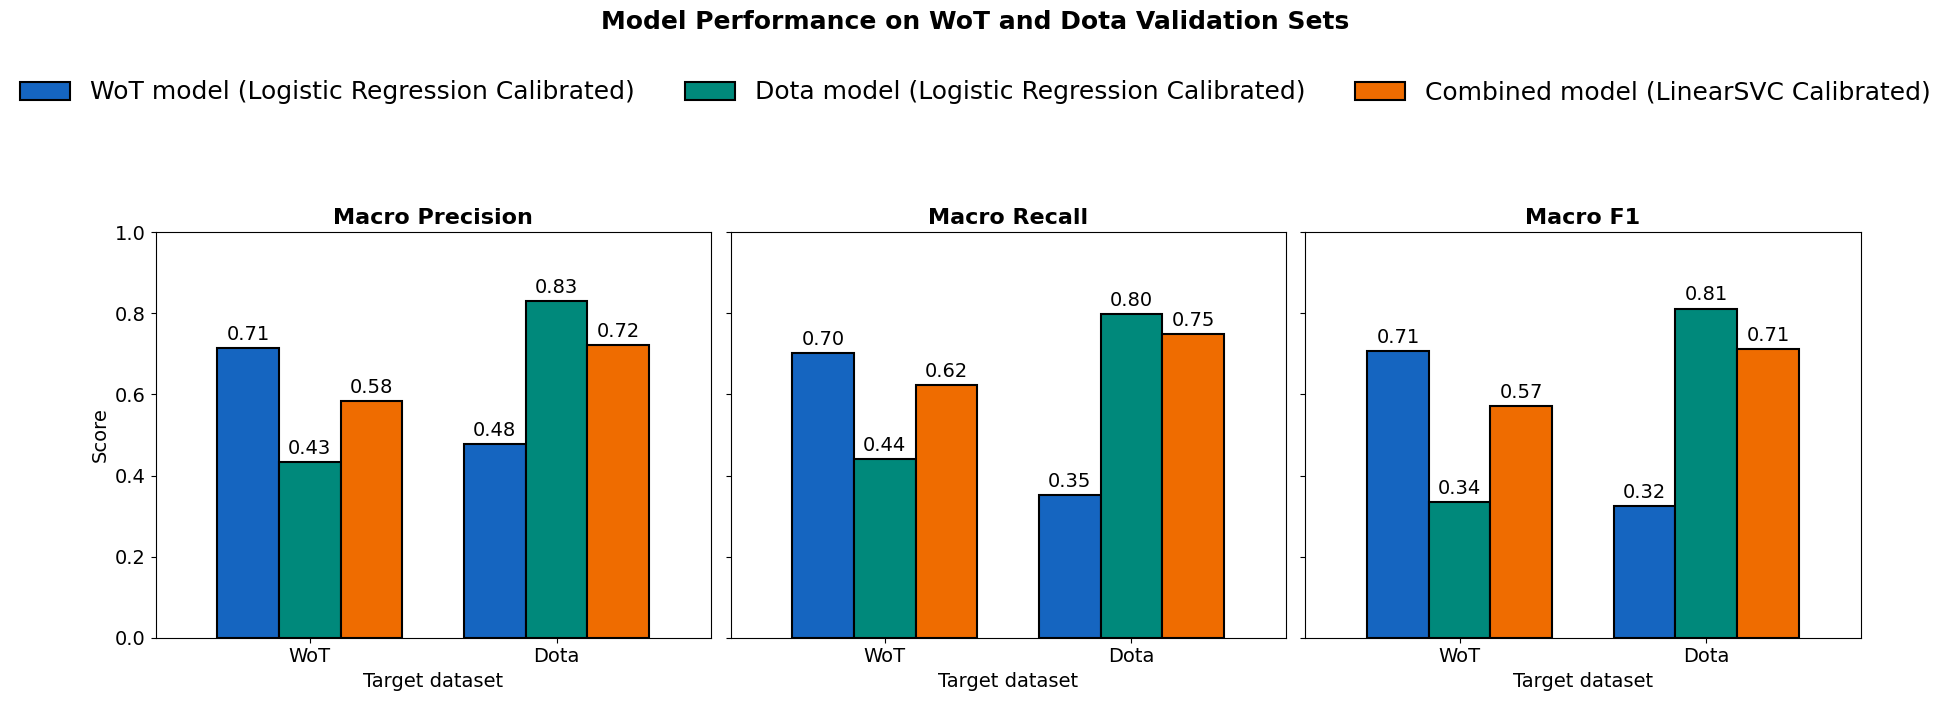

In [46]:
# performance comparison: single-game models vs combined model
# grouped by target dataset, with macro precision / recall / f1

combined_class_names = ['Non-Toxic', 'Mild Toxicity', 'Severe Toxicity']

def load_val_split(load_fn, scheme=None):
    df = load_fn('val').copy()
    if scheme is not None:
        df['label'] = df['label'].astype(int).map(scheme)
    return df['message'], df['label']

def collect_metrics(model_name, target_name, pipe, X, y, class_names):
    report = classification_report(
        y,
        pipe.predict(X),
        target_names=class_names,
        zero_division=0,
        output_dict=True
    )
    return {
        'Model': model_name,
        'Target': target_name,
        'Macro Precision': report['macro avg']['precision'],
        'Macro Recall': report['macro avg']['recall'],
        'Macro F1': report['macro avg']['f1-score'],
        'Weighted F1': report['weighted avg']['f1-score'],
    }

# validation splits
X_wot_val, y_wot_val = load_val_split(load_wot, WOT_SCHEME_3)
X_dota_val, y_dota_val = load_val_split(load_dota, DOTA_SCHEME_3)
X_comb_val, y_comb_val = load_val_split(load_combined_3class, scheme=None)

rows = [
    collect_metrics('WoT model (Logistic Regression Calibrated)', 'WoT', wot_lr_calibrated, X_wot_val, y_wot_val, WOT_CLASS_NAMES[3]),
    collect_metrics('WoT model (Logistic Regression Calibrated)', 'Dota', wot_lr_calibrated, X_dota_val, y_dota_val, DOTA_CLASS_NAMES[3]),
    collect_metrics('Dota model (Logistic Regression Calibrated)', 'WoT', dota_lr_calibrated, X_wot_val, y_wot_val, WOT_CLASS_NAMES[3]),
    collect_metrics('Dota model (Logistic Regression Calibrated)', 'Dota', dota_lr_calibrated, X_dota_val, y_dota_val, DOTA_CLASS_NAMES[3]),
    collect_metrics('Combined model (LinearSVC Calibrated)', 'WoT', combined_svc_calibrated, X_wot_val, y_wot_val, WOT_CLASS_NAMES[3]),
    collect_metrics('Combined model (LinearSVC Calibrated)', 'Dota', combined_svc_calibrated, X_dota_val, y_dota_val, DOTA_CLASS_NAMES[3]),
    collect_metrics('Combined model (LinearSVC Calibrated)', 'Combined', combined_svc_calibrated, X_comb_val, y_comb_val, combined_class_names),
]

perf_df = pd.DataFrame(rows)

# nicer ordering
target_order = ['WoT', 'Dota', 'Combined']
model_order = ['WoT model (Logistic Regression Calibrated)', 'WoT model (LinearSVC Calibrated)', 'Dota model (Logistic Regression Calibrated)', 'Dota model (LinearSVC Calibrated)', 'Combined model (LinearSVC Calibrated)']
perf_df['Target'] = pd.Categorical(perf_df['Target'], categories=target_order, ordered=True)
perf_df['Model'] = pd.Categorical(perf_df['Model'], categories=model_order, ordered=True)
perf_df = perf_df.sort_values(['Target', 'Model']).reset_index(drop=True)

display(perf_df.round(4))

# plot only comparable target datasets for grouped model comparison
plot_df = perf_df[perf_df['Target'].isin(['WoT', 'Dota'])].copy()

metrics = ['Macro Precision', 'Macro Recall', 'Macro F1']
colors = {
    'WoT model (Logistic Regression Calibrated)': '#1565C0',
    'Dota model (Logistic Regression Calibrated)': '#00897B',
    'Combined model (LinearSVC Calibrated)': '#EF6C00',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, metric in zip(axes, metrics):
    pivot_df = plot_df.pivot(index='Target', columns='Model', values=metric)
    pivot_df = pivot_df[['WoT model (Logistic Regression Calibrated)', 
                         'Dota model (Logistic Regression Calibrated)', 'Combined model (LinearSVC Calibrated)']]

    pivot_df.plot(
        kind='bar',
        ax=ax,
        color=[colors[col] for col in pivot_df.columns],
        width=0.75, 
        edgecolor='black',
        linewidth=1.5,
    )

    ax.set_title(metric, fontweight='bold', fontsize = 16)
    ax.set_xlabel('Target dataset', fontsize = 14)
    ax.set_ylabel('Score', fontsize = 14)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=0, labelsize = 14)
    ax.tick_params(axis='y', labelsize = 14)

    # numbers on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=14)

    ax.legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,
    frameon=False,
    fontsize=18
)

fig.suptitle('Model Performance on WoT and Dota Validation Sets',
             fontweight='bold', y=1.16, fontsize = 18)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## Section 4: Interpretability

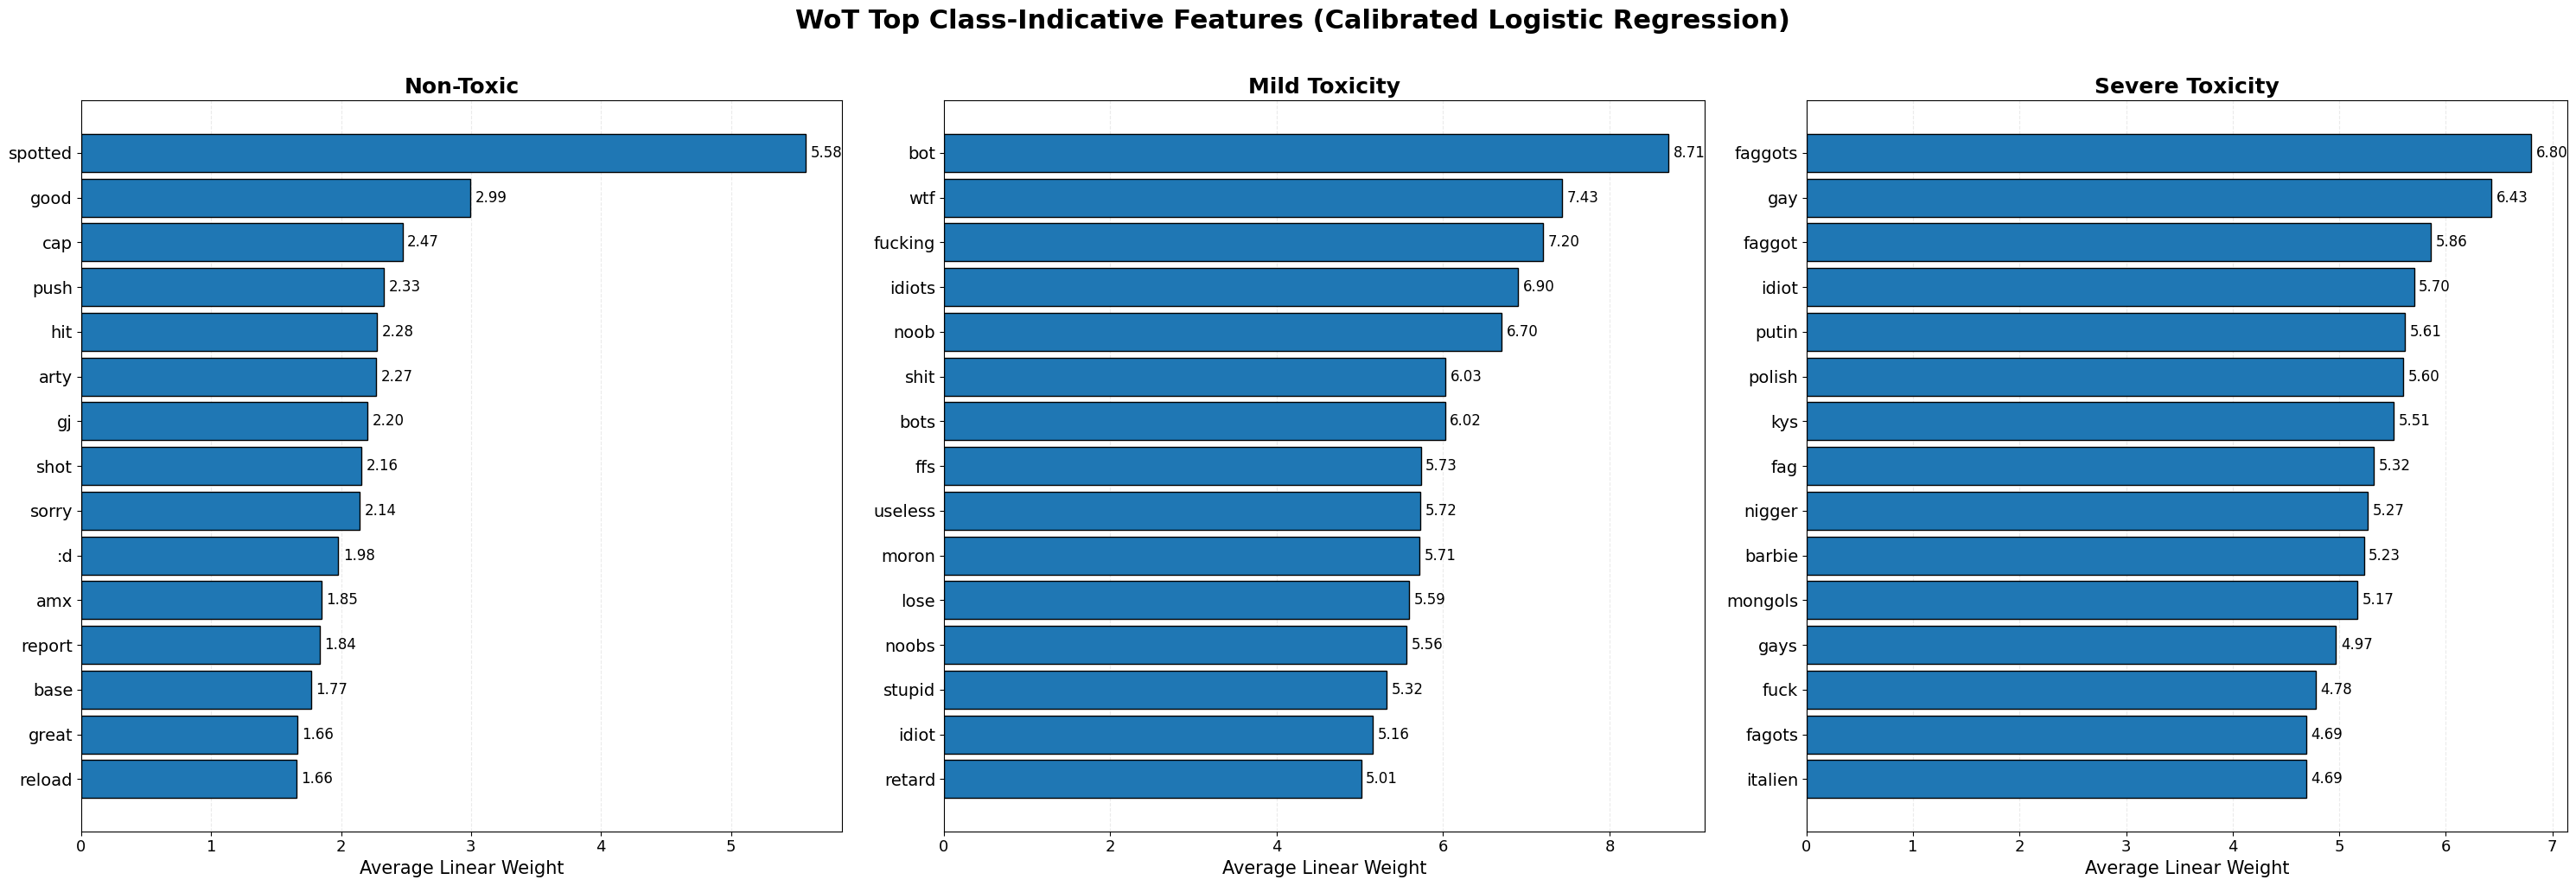

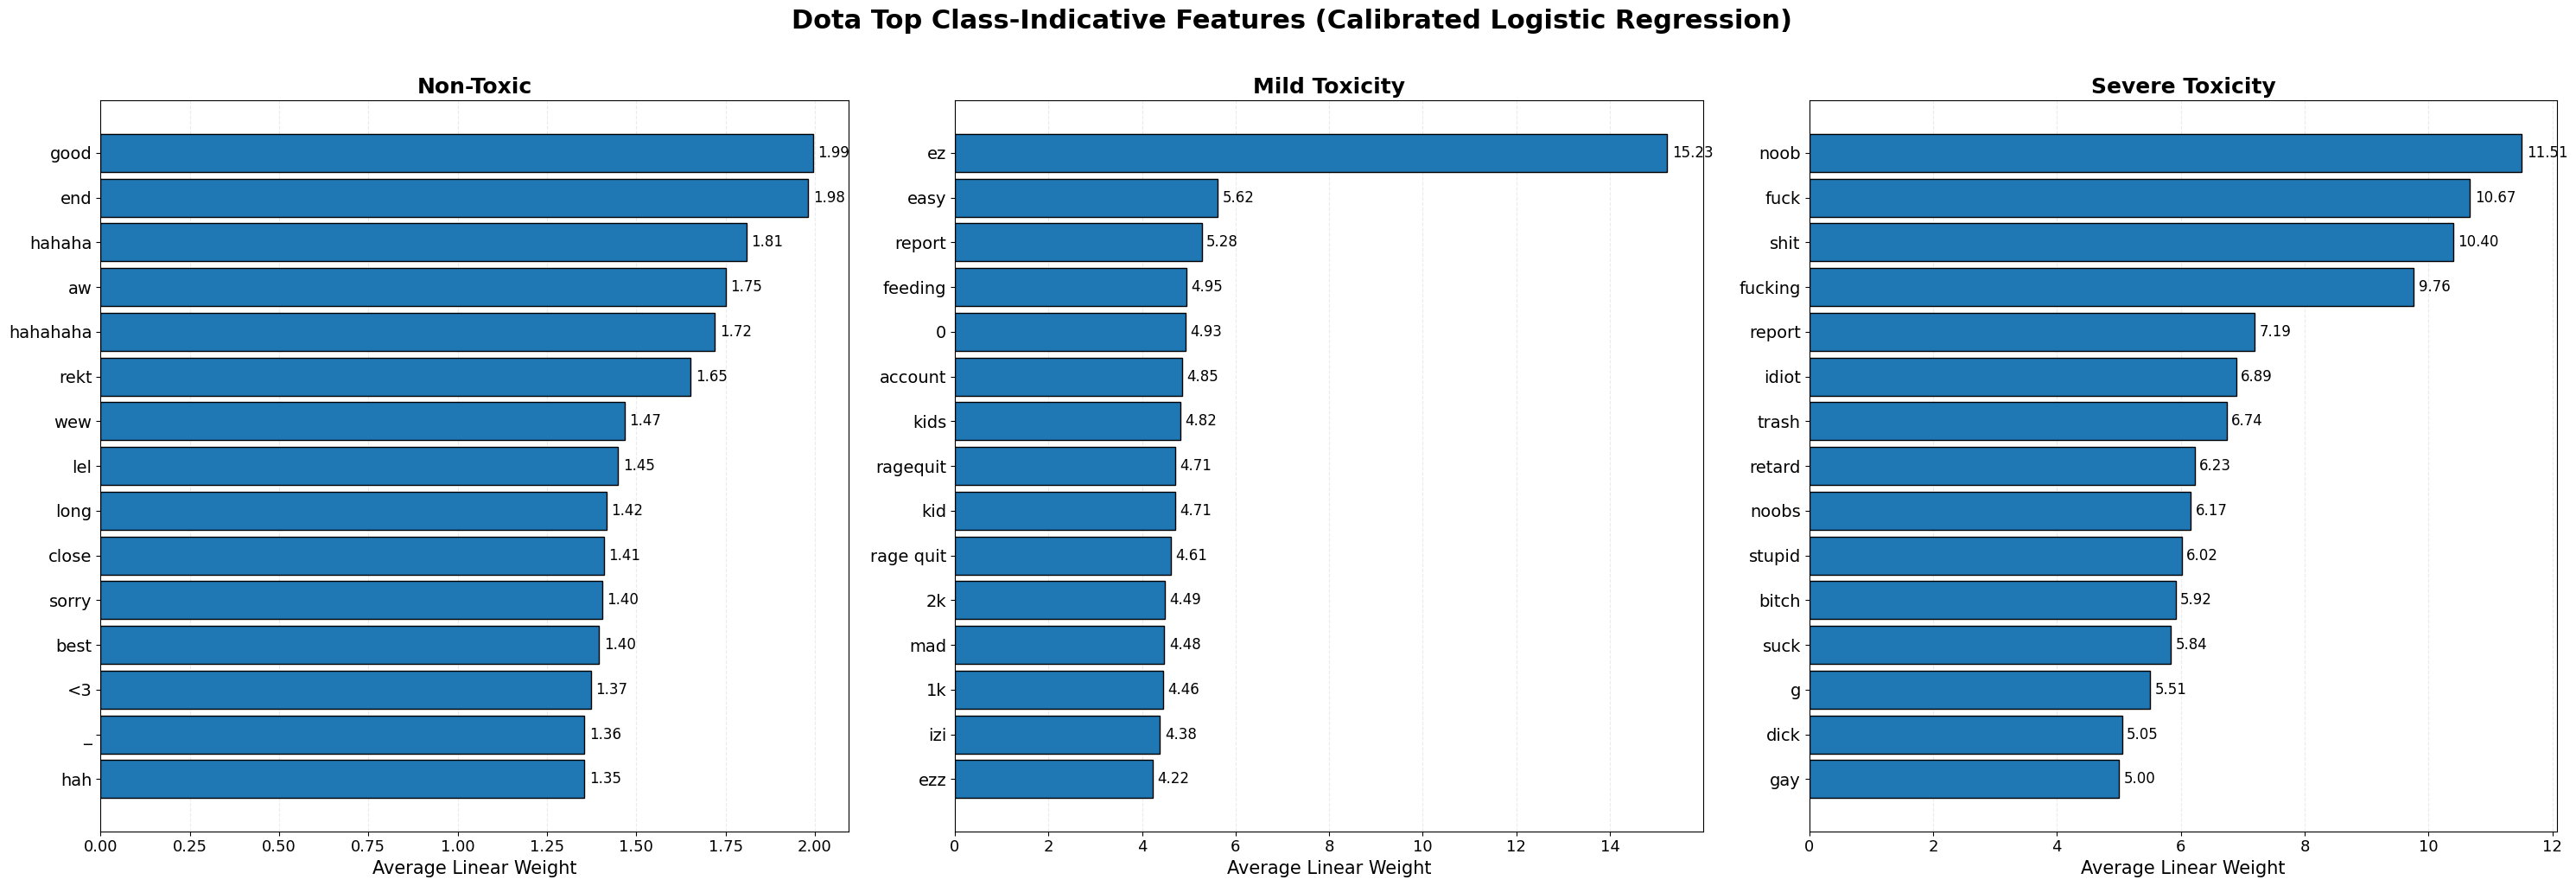

In [47]:
def plot_top_positive_features_all_classes_calibrated(pipe, class_names, title, top_n=15):
    clf = pipe.named_steps['clf']
    tfidf = pipe.named_steps['tfidf']
    feature_names = np.array(tfidf.get_feature_names_out())

    # average coefficients across calibrated folds
    coefs = np.mean(
        [cal.estimator.coef_ for cal in clf.calibrated_classifiers_],
        axis=0
    )  # shape: (n_classes, n_features)

    n_classes = len(class_names)
    fig, axes = plt.subplots(1, n_classes, figsize=(10 * n_classes, 10))
    if n_classes == 1:
        axes = [axes]

    for class_idx, ax in enumerate(axes):
        class_coef = coefs[class_idx]
        top_idx = np.argsort(class_coef)[-top_n:]

        vals = class_coef[top_idx]
        names = feature_names[top_idx]

        order = np.argsort(vals)
        vals = vals[order]
        names = names[order]

        bars = ax.barh(
            names,
            vals,
            color='#1f77b4',
            edgecolor='black',
            linewidth=1.0,
            height=0.85
        )

        ax.set_title(class_names[class_idx], fontweight='bold', fontsize=18)
        ax.set_xlabel('Average Linear Weight', fontsize=15)
        ax.tick_params(axis='y', labelsize=14)
        ax.tick_params(axis='x', labelsize=13)
        ax.grid(axis='x', linestyle='--', alpha=0.25)
        ax.set_axisbelow(True)

        ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=12)

    plt.suptitle(title, fontweight='bold', fontsize=22, y=1.02)
    plt.tight_layout()
    plt.show()

# WoT
plot_top_positive_features_all_classes_calibrated(
    wot_lr_calibrated,
    WOT_CLASS_NAMES[wot_best_n],
    'WoT Top Class-Indicative Features (Calibrated Logistic Regression)',
    top_n=15
)

# Dota
plot_top_positive_features_all_classes_calibrated(
    dota_lr_calibrated,
    DOTA_CLASS_NAMES[dota_best_n],
    'Dota Top Class-Indicative Features (Calibrated Logistic Regression)',
    top_n=15
)

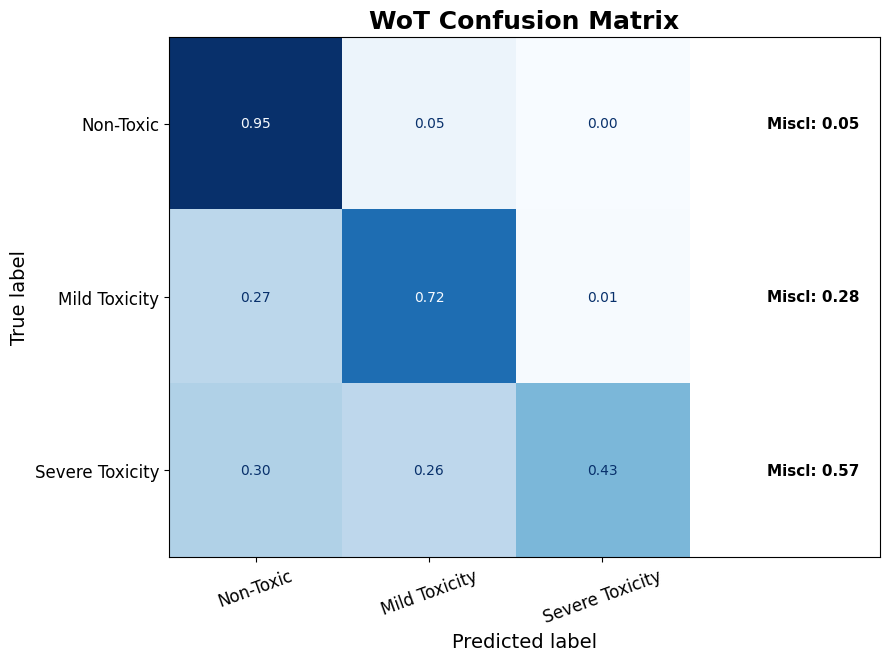

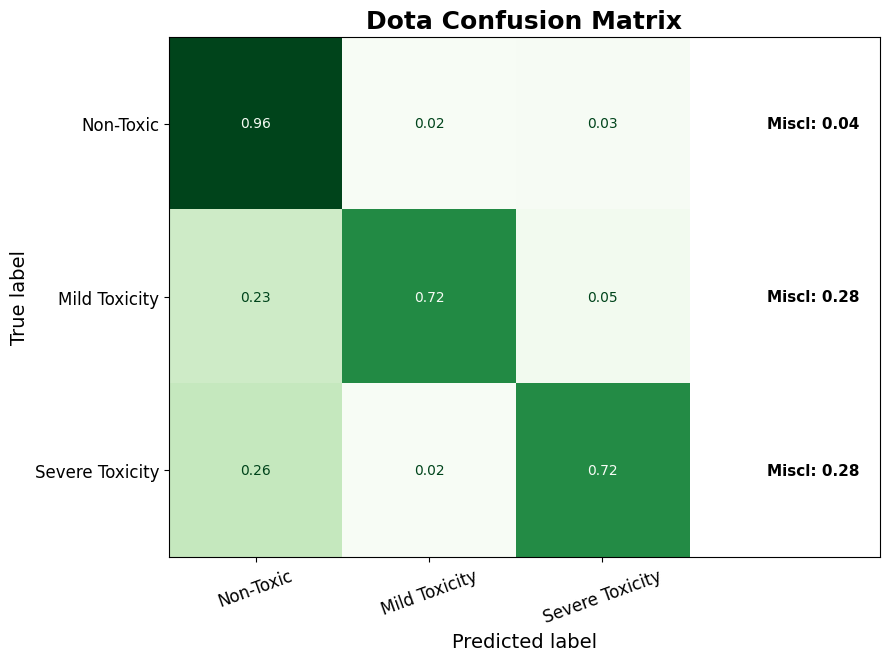

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix_for_pipe(pipe, load_fn, scheme, class_names, title, cmap='Blues'):
    # validation data 
    val_df = load_fn('val').copy()
    if scheme is not None:
        val_df['label'] = val_df['label'].astype(int).map(scheme)

    # features and labels
    X_val = val_df['message']
    y_val = val_df['label']

    # predictions
    y_pred = pipe.predict(X_val)

    # normalised confusion matrix
    cm = confusion_matrix(
        y_val,
        y_pred,
        labels=list(range(len(class_names))),
        normalize='true'
    )

    # plot 
    fig, ax = plt.subplots(figsize=(9, 7))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )
    disp.plot(ax=ax, cmap=cmap, colorbar=False, values_format='.2f')

    # titles and axis
    ax.set_title(title, fontweight='bold', fontsize=18)
    ax.set_xlabel('Predicted label', fontsize=14)
    ax.set_ylabel('True label', fontsize=14)
    ax.tick_params(axis='x', labelrotation=20, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # add misclassification rate for each true class
    for i, cls_name in enumerate(class_names):
        misclf = 1 - cm[i, i]
        ax.text(
            len(class_names) - 0.05,
            i,
            f'Miscl: {misclf:.2f}',
            va='center',
            ha='left',
            fontsize=11,
            color='black',
            fontweight='bold'
        )

    # extra room on the right for misclassification text
    ax.set_xlim(-0.5, len(class_names) + 0.6)

    plt.tight_layout()
    plt.show()


# WoT
plot_confusion_matrix_for_pipe(
    wot_lr_calibrated,
    load_wot,
    WOT_SCHEME_3,
    WOT_CLASS_NAMES[3],
    'WoT Confusion Matrix',
    cmap='Blues'
)

# Dota
plot_confusion_matrix_for_pipe(
    dota_lr_calibrated,
    load_dota,
    DOTA_SCHEME_3,
    DOTA_CLASS_NAMES[3],
    'Dota Confusion Matrix',
    cmap='Greens'
)